José Herrera Ortiz - Universidad Pontificia Comillas ICAI

# Exploratory Data Analysis (EDA)

## Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/rendimiento_estudiantes.csv", sep=";")
df.head()

,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


### 1. Data Preparation

In [3]:
df.shape

(4424, 37)

In [4]:
df.isnull().sum()

estado_civil                         0
modo_solicitud                       0
orden_solicitud                      0
curso                                0
asistencia_diurna_vespertina         0
cualificacion_previa                 0
nota_cualificacion_previa            0
nacionalidad                         0
cualificacion_madre                  0
cualificacion_padre                  0
ocupacion_madre                      0
ocupacion_padre                      0
nota_admision                        0
desplazado                           0
necesidades_educativas_especiales    0
deudor                               0
matricula_al_dia                     0
genero                               0
becado                               0
edad_al_matricularse                 0
internacional                        0
asignaturas_1sem_convalidadas        0
asignaturas_1sem_matriculadas        0
asignaturas_1sem_evaluadas           0
asignaturas_1sem_aprobadas           0
nota_media_1sem          

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['estado_civil', 'modo_solicitud', 'orden_solicitud', 'curso',
       'asistencia_diurna_vespertina', 'cualificacion_previa',
       'nota_cualificacion_previa', 'nacionalidad', 'cualificacion_madre',
       'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre',
       'nota_admision', 'desplazado', 'necesidades_educativas_especiales',
       'deudor', 'matricula_al_dia', 'genero', 'becado',
       'edad_al_matricularse', 'internacional',
       'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
       'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
       'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion',
       'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
       'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
       'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo',
       'tasa_inflacion', 'pib', 'objetivo'],
      dtype='object')

### 2. Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424 non-null   objec

In [8]:
print(df.select_dtypes(include="object").shape[1])
print(df.select_dtypes(include="float64").shape[1])
print(df.select_dtypes(include="int64").shape[1])

18
7
12


In [9]:
df["objetivo"].value_counts()

objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

In [10]:
df["objetivo"].value_counts(normalize=True)

objetivo
graduado       0.499322
abandono       0.321203
matriculado    0.179476
Name: proportion, dtype: float64

In [11]:
counts = df["objetivo"].value_counts()
percentages = df["objetivo"].value_counts(normalize=True)

result = pd.concat([counts, percentages], axis=1)
result.columns = ["count", "percentage"]

print(result)

             count  percentage
objetivo                      
graduado      2209    0.499322
abandono      1421    0.321203
matriculado    794    0.179476


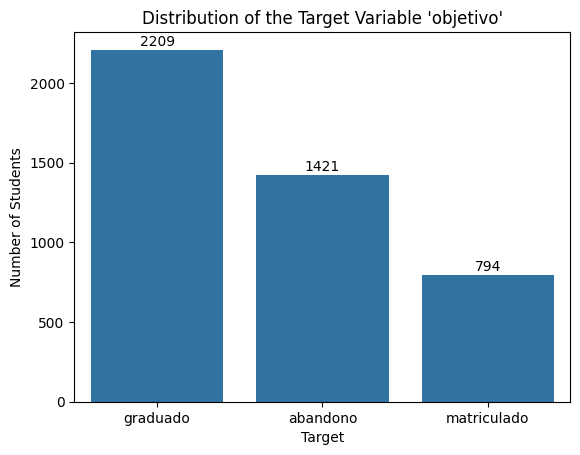

In [12]:
count = df['objetivo'].value_counts()

ax = sns.barplot(x=count.index, y=count.values)

ax.set_xlabel("Target")
ax.set_ylabel("Number of Students")
ax.set_title("Distribution of the Target Variable 'objetivo'")

ax.bar_label(
    ax.containers[0],
    labels=count.values,
    padding=1
)

plt.show()

Splitting variables by type

In [13]:
target = "objetivo"

continuous_variables = [
    "nota_cualificacion_previa",
    "nota_admision",
    "nota_media_1sem",
    "nota_media_2sem",
    "tasa_desempleo",
    "tasa_inflacion",
    "pib"
]

discrete_variables = [
    "orden_solicitud",
    "edad_al_matricularse",
    "asignaturas_1sem_convalidadas",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_aprobadas",
    "asignaturas_1sem_sin_evaluacion",
    "asignaturas_2sem_convalidadas",
    "asignaturas_2sem_matriculadas",
    "asignaturas_2sem_evaluadas",
    "asignaturas_2sem_aprobadas",
    "asignaturas_2sem_sin_evaluacion"
]

categorical_variables = [
    col for col in df.columns
    if col not in continuous_variables + discrete_variables + [target]
]

print(f"Number of continuous variables: {len(continuous_variables)}")
print(f"Number of discrete variables: {len(discrete_variables)}")
print(f"Number of categorical variables: {len(categorical_variables)}")
print(f"In addition to the target variable: {target}")

Number of continuous variables: 7
Number of discrete variables: 12
Number of categorical variables: 17
In addition to the target variable: objetivo


In [14]:
variables_numericas_dtype = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_numericas_manual = continuous_variables + discrete_variables

print("Numerical by dtype:", variables_numericas_dtype)
print("Manual numericals:", variables_numericas_manual)

missing = set(variables_numericas_dtype) - set(variables_numericas_manual)
to_spare = set(variables_numericas_manual) - set(variables_numericas_dtype)

print("Not classified numerical:", missing)
print("Nothing:", to_spare)

Numerical by dtype: ['orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']
Manual numericals: ['nota_cualificacion_previa', 'nota_admision', 'nota_media_1sem', 'nota_media_2sem', 'tasa_desempleo', 'tasa_inflacion', 'pib', 'orden_solicitud', 'edad_al_matricularse', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'asignatur

# A. EDA of continuous variables

In [15]:
df[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
nota_cualificacion_previa,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
nota_admision,4424.0,126.978119,14.482001,95.00,117.90,126.100000,134.800000,190.000000
nota_media_1sem,4424.0,10.640822,4.843663,0.00,11.00,12.285714,13.400000,18.875000
nota_media_2sem,4424.0,10.230206,5.210808,0.00,10.75,12.200000,13.333333,18.571429
tasa_desempleo,4424.0,11.566139,2.663850,7.60,9.40,11.100000,13.900000,16.200000
tasa_inflacion,4424.0,1.228029,1.382711,-0.80,0.30,1.400000,2.600000,3.700000
pib,4424.0,0.001969,2.269935,-4.06,-1.70,0.320000,1.790000,3.510000


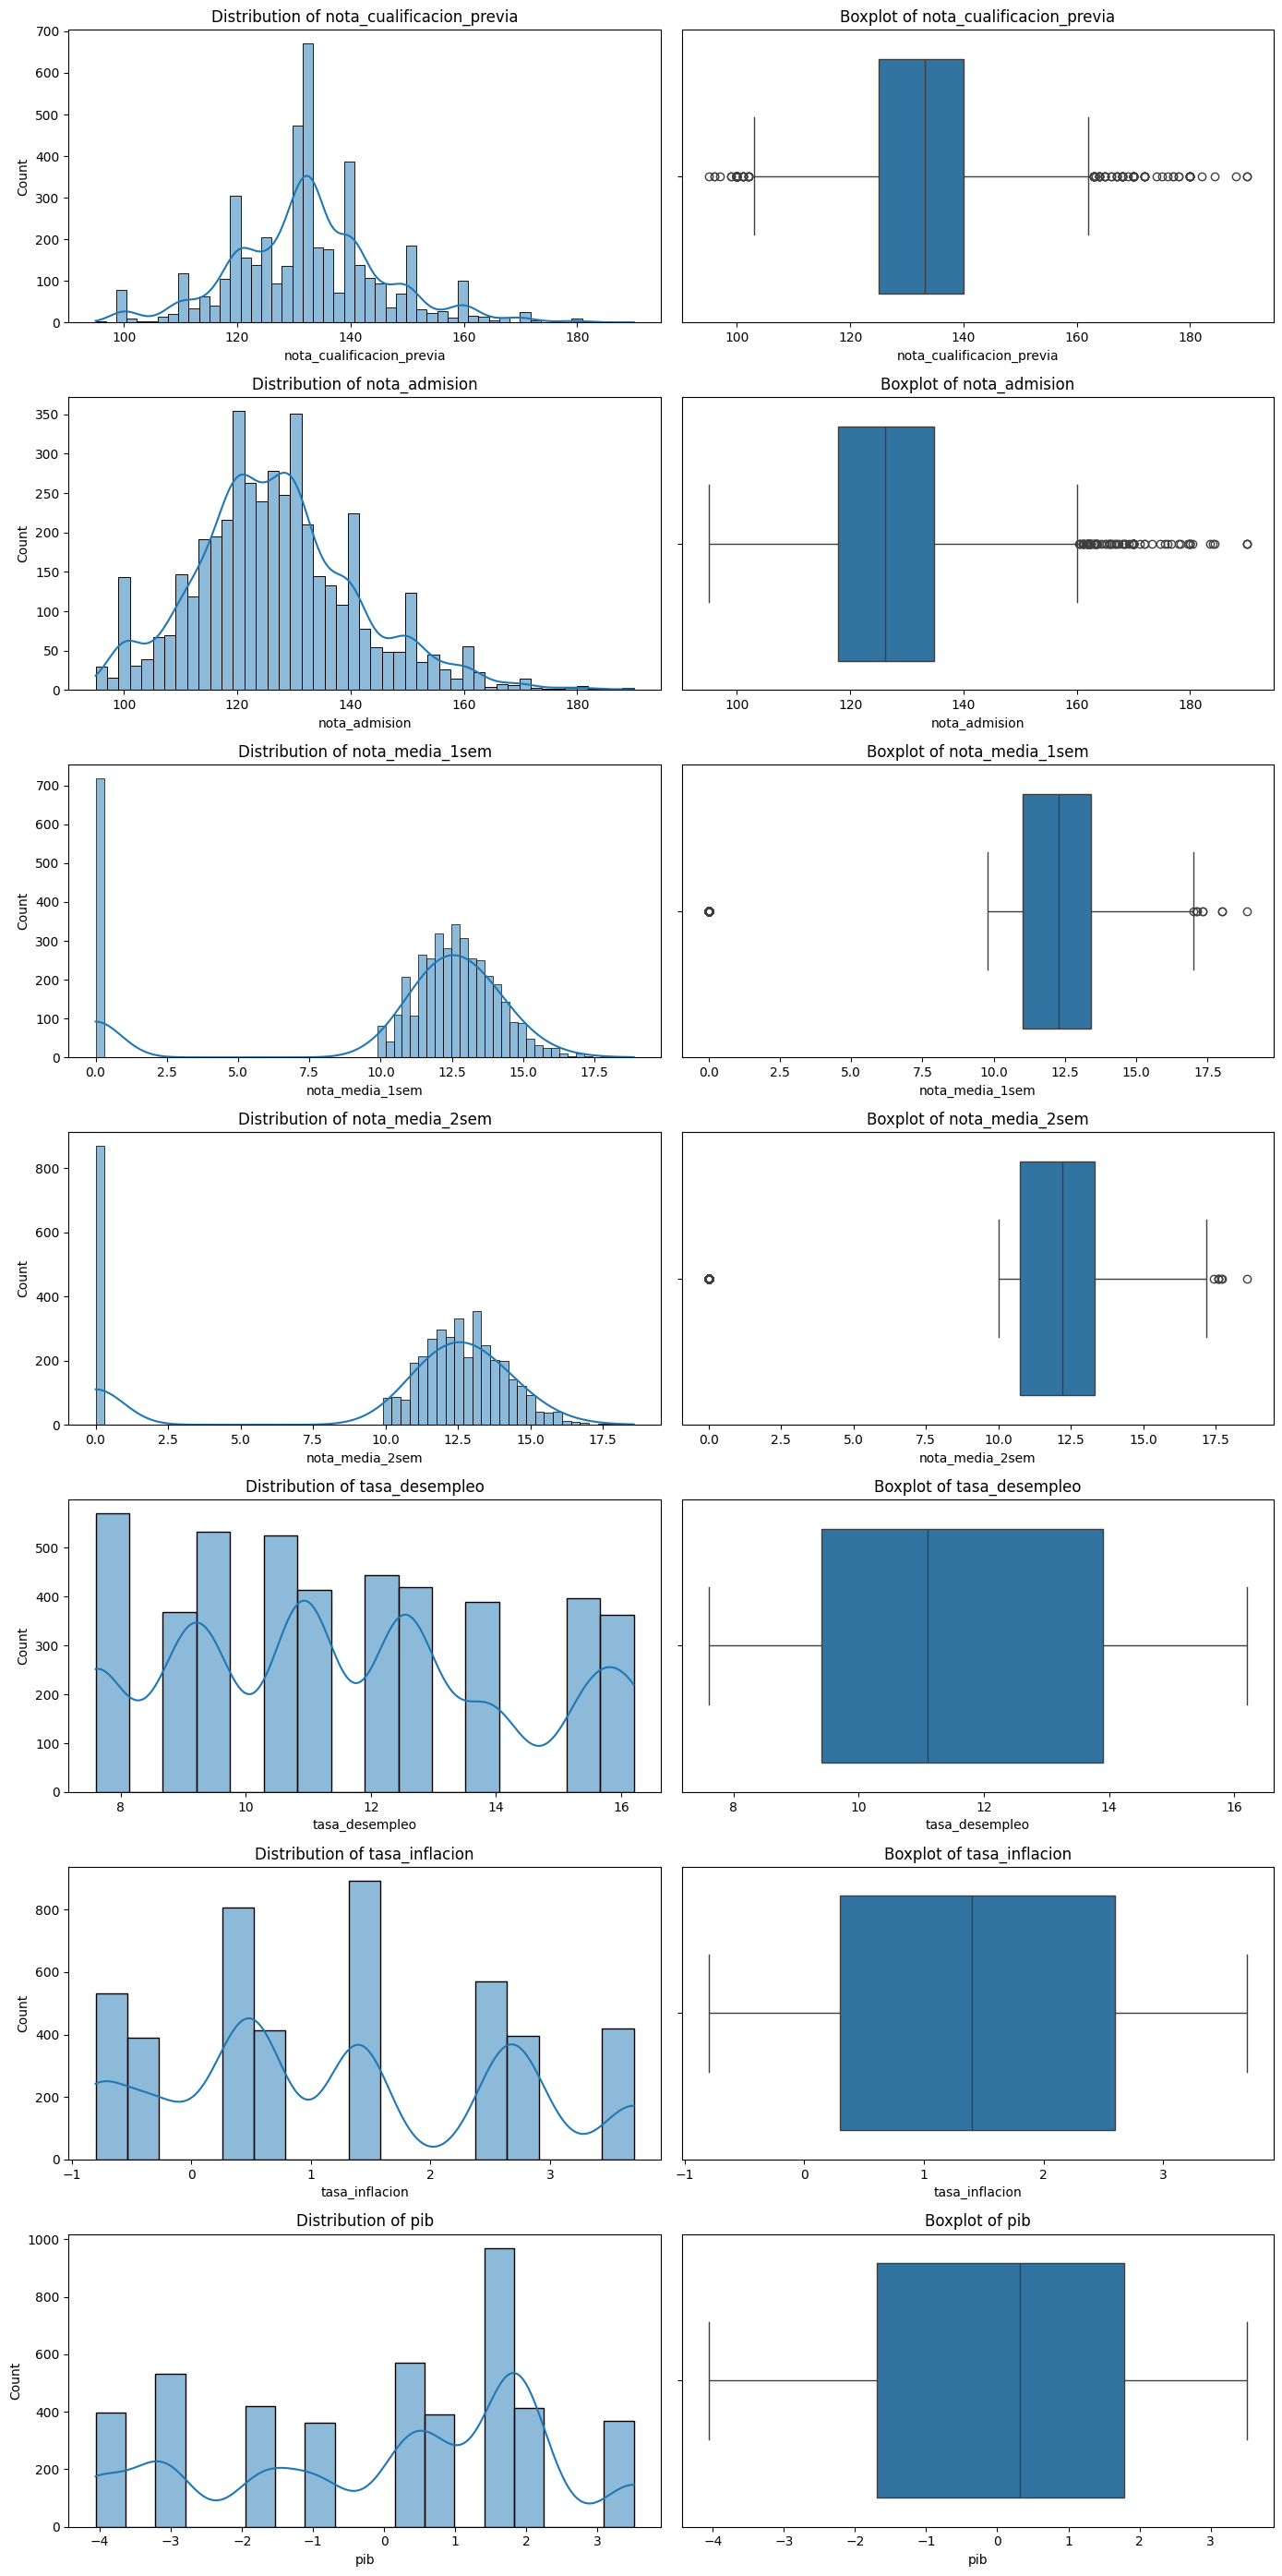

In [16]:
fig, axes = plt.subplots(len(continuous_variables), 2, figsize=(14, 4 * len(continuous_variables)))

if len(continuous_variables) == 1:
    axes = [axes]

for i, col in enumerate(continuous_variables):
    ax_hist = axes[i][0]
    ax_box = axes[i][1]

    sns.histplot(df[col], kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

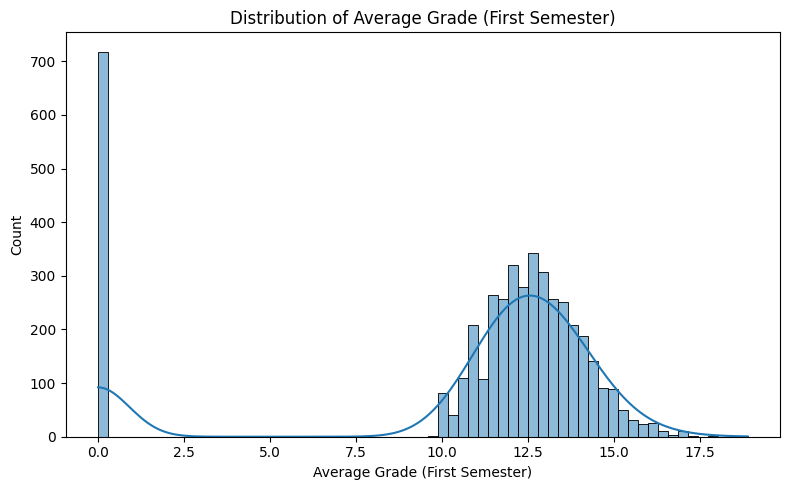

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df["nota_media_1sem"], kde=True)

plt.title("Distribution of Average Grade (First Semester)")
plt.xlabel("Average Grade (First Semester)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

One value in range (0, 10).

In [18]:
df["nota_media_1sem"].value_counts().sort_index(ascending=True)

nota_media_1sem
0.000000     718
9.800000       1
10.000000     82
10.166667      1
10.200000      8
            ... 
17.111111      1
17.125000      1
17.333333      2
18.000000      2
18.875000      1
Name: count, Length: 805, dtype: int64

IQR without deleting

In [19]:
from utils_project import detect_iqr_outliers

In [20]:
continuous_outliers_table = detect_iqr_outliers(df, continuous_variables)
display(continuous_outliers_table)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
3,nota_media_2sem,10.75,13.333333,2.583333,6.875,17.208333,877,19.82
2,nota_media_1sem,11.00,13.400000,2.400000,7.400,17.000000,726,16.41
0,nota_cualificacion_previa,125.00,140.000000,15.000000,102.500,162.500000,179,4.05
1,nota_admision,117.90,134.800000,16.900000,92.550,160.150000,86,1.94
4,tasa_desempleo,9.40,13.900000,4.500000,2.650,20.650000,0,0.00
5,tasa_inflacion,0.30,2.600000,2.300000,-3.150,6.050000,0,0.00
6,pib,-1.70,1.790000,3.490000,-6.935,7.025000,0,0.00


# B. EDA of discrete variables

In [21]:
df[discrete_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
orden_solicitud,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
edad_al_matricularse,4424.0,23.265145,7.587816,17.0,19.0,20.0,25.0,70.0
asignaturas_1sem_convalidadas,4424.0,0.709991,2.360507,0.0,0.0,0.0,0.0,20.0
asignaturas_1sem_matriculadas,4424.0,6.270570,2.480178,0.0,5.0,6.0,7.0,26.0
asignaturas_1sem_evaluadas,4424.0,8.299051,4.179106,0.0,6.0,8.0,10.0,45.0
asignaturas_1sem_aprobadas,4424.0,4.706600,3.094238,0.0,3.0,5.0,6.0,26.0
asignaturas_1sem_sin_evaluacion,4424.0,0.137658,0.690880,0.0,0.0,0.0,0.0,12.0
asignaturas_2sem_convalidadas,4424.0,0.541817,1.918546,0.0,0.0,0.0,0.0,19.0
asignaturas_2sem_matriculadas,4424.0,6.232143,2.195951,0.0,5.0,6.0,7.0,23.0
asignaturas_2sem_evaluadas,4424.0,8.063291,3.947951,0.0,6.0,8.0,10.0,33.0


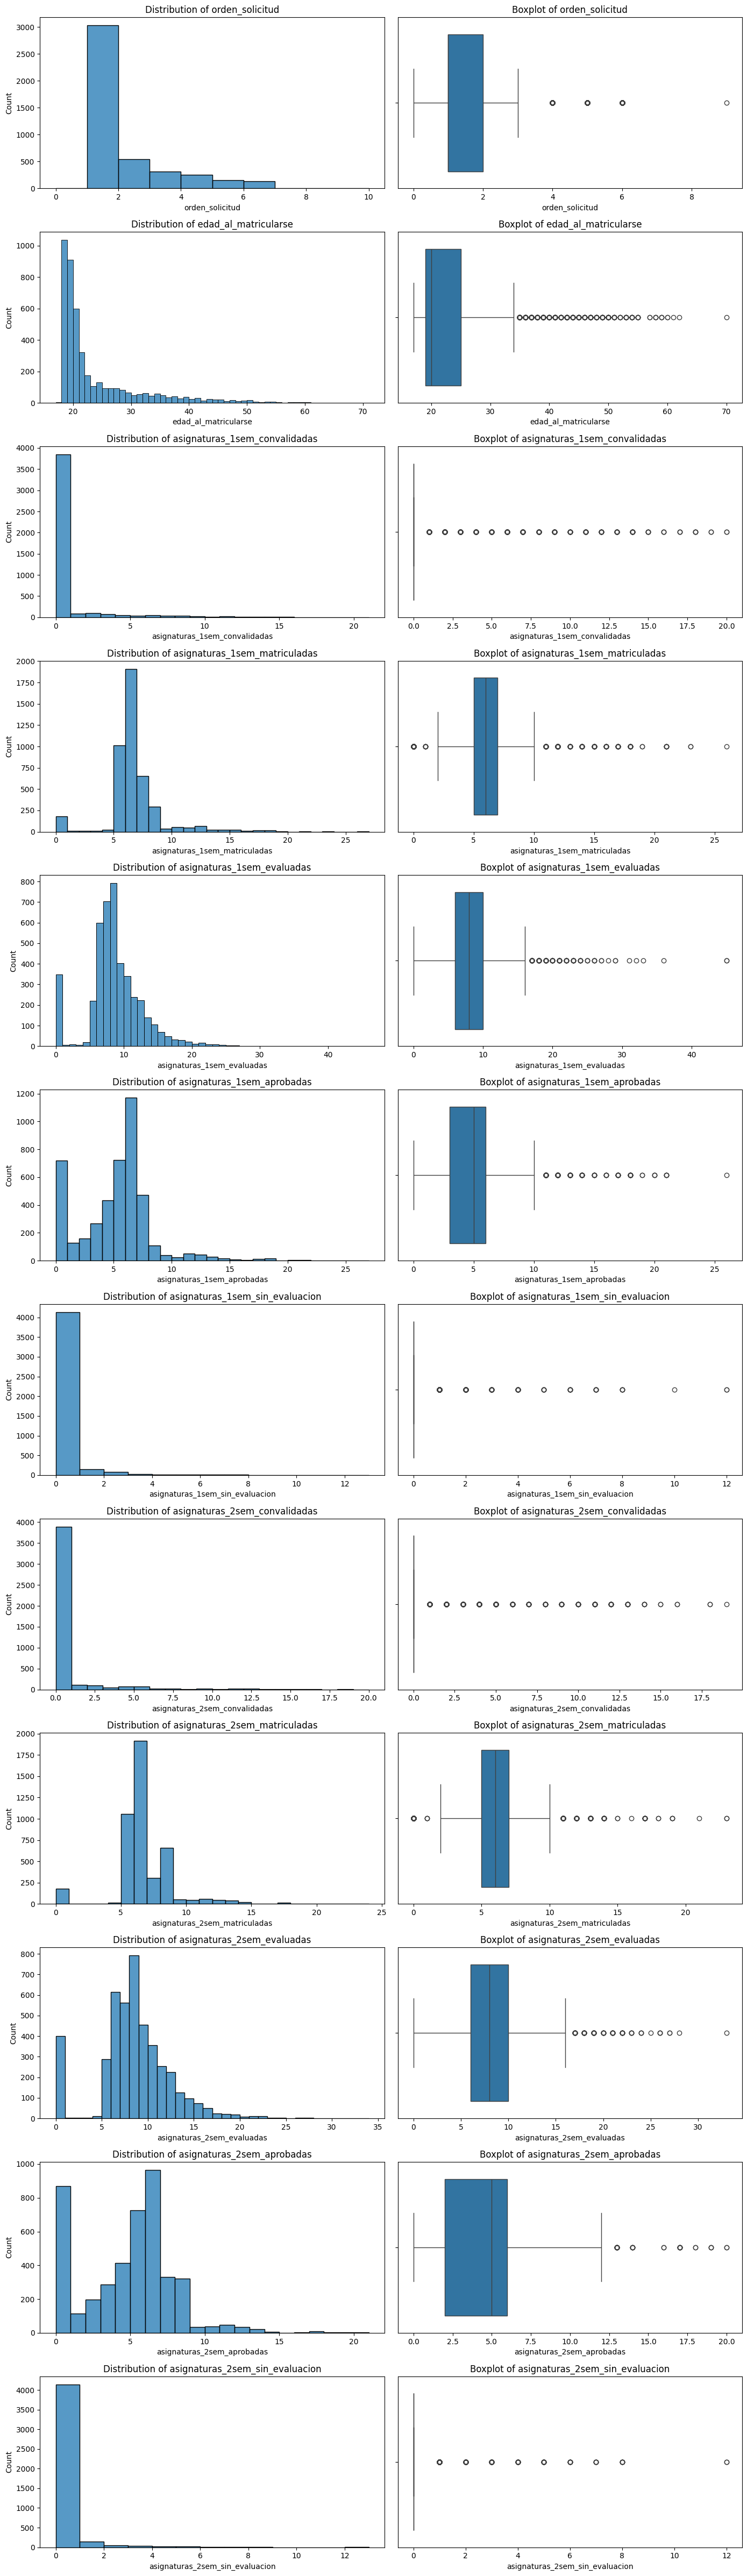

In [22]:
fig, axes = plt.subplots(len(discrete_variables), 2, figsize=(14, 4 * len(discrete_variables)))

if len(discrete_variables) == 1:
    axes = [axes]

for i, col in enumerate(discrete_variables):
    ax_hist = axes[i][0]
    ax_box = axes[i][1]

    sns.histplot(
        df[col],
        bins=range(int(df[col].min()), int(df[col].max()) + 2),
        ax=ax_hist
    )
    ax_hist.set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [23]:
discrete_outliers_table = detect_iqr_outliers(df, discrete_variables)
display(discrete_outliers_table)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
2,asignaturas_1sem_convalidadas,0.0,0.0,0.0,0.0,0.0,577,13.04
0,orden_solicitud,1.0,2.0,1.0,-0.5,3.5,541,12.23
7,asignaturas_2sem_convalidadas,0.0,0.0,0.0,0.0,0.0,530,11.98
1,edad_al_matricularse,19.0,25.0,6.0,10.0,34.0,441,9.97
3,asignaturas_1sem_matriculadas,5.0,7.0,2.0,2.0,10.0,424,9.58
8,asignaturas_2sem_matriculadas,5.0,7.0,2.0,2.0,10.0,369,8.34
6,asignaturas_1sem_sin_evaluacion,0.0,0.0,0.0,0.0,0.0,294,6.65
11,asignaturas_2sem_sin_evaluacion,0.0,0.0,0.0,0.0,0.0,282,6.37
5,asignaturas_1sem_aprobadas,3.0,6.0,3.0,-1.5,10.5,180,4.07
4,asignaturas_1sem_evaluadas,6.0,10.0,4.0,0.0,16.0,158,3.57


I decided not to delete any value.  

Outliers are seen, but would only have been deleted if it was something weird.

# C. EDA of categorical variables

In [24]:
for col in categorical_variables:
    tabla = pd.crosstab(df[col], df["objetivo"], normalize="index")
    display(tabla)

objetivo,abandono,graduado,matriculado
estado_civil,,,
casado/a,0.472296,0.390501,0.137203
divorciado/a,0.461538,0.362637,0.175824
separado/a_legalmente,0.666667,0.166667,0.166667
soltero/a,0.302118,0.514162,0.183720
union_de_hecho,0.440000,0.440000,0.120000
viudo/a,0.250000,0.250000,0.500000


objetivo,abandono,graduado,matriculado
modo_solicitud,,,
1a_fase_contingente_especial_azores,0.125000,0.375000,0.500000
1a_fase_contingente_especial_madeira,0.131579,0.657895,0.210526
1a_fase_contingente_general,0.201991,0.622365,0.175644
2a_fase_contingente_general,0.293578,0.524083,0.182339
3a_fase_contingente_general,0.362903,0.508065,0.129032
cambio_de_curso,0.368590,0.391026,0.240385
cambio_de_institucion_curso,0.338983,0.440678,0.220339
cambio_de_institucion_curso_internacional,0.000000,1.000000,0.000000
estudiante_internacional_licenciatura,0.166667,0.500000,0.333333


objetivo,abandono,graduado,matriculado
curso,,,
agronomia,0.409524,0.414286,0.176190
animacion_y_diseno_multimedia,0.381395,0.446512,0.172093
diseno_de_comunicacion,0.225664,0.588496,0.185841
educacion_basica,0.442708,0.296875,0.260417
enfermeria,0.154047,0.715405,0.130548
enfermeria_veterinaria,0.267062,0.510386,0.222552
equicultura,0.553191,0.297872,0.148936
gestion,0.352632,0.363158,0.284211
gestion_de_publicidad_y_marketing,0.354478,0.466418,0.179104


objetivo,abandono,graduado,matriculado
asistencia_diurna_vespertina,,,
diurna,0.308044,0.509515,0.182441
vespertina,0.428571,0.416149,0.155280


objetivo,abandono,graduado,matriculado
cualificacion_previa,,,
10o_ano,1.000000,0.000000,0.000000
10o_ano_no_completado,0.500000,0.500000,0.000000
11o_ano_no_completado,0.750000,0.250000,0.000000
12o_ano_no_completado,1.000000,0.000000,0.000000
asistencia_previa_a_educacion_superior,0.437500,0.500000,0.062500
curso_de_especializacion_tecnologica,0.315068,0.433790,0.251142
curso_tecnico_superior_profesional,0.166667,0.611111,0.222222
educacion_basica_2o_ciclo_o_equivalente,0.428571,0.428571,0.142857
educacion_basica_3er_ciclo_o_equivalente,0.641975,0.277778,0.080247


...

objetivo,abandono,graduado,matriculado
deudor,,,
no,0.282836,0.537618,0.179546
si,0.620278,0.200795,0.178926


objetivo,abandono,graduado,matriculado
matricula_al_dia,,,
no,0.865530,0.054924,0.079545
si,0.247433,0.559548,0.193018


objetivo,abandono,graduado,matriculado
genero,,,
hombre,0.450514,0.352185,0.197301
mujer,0.251046,0.579149,0.169805


objetivo,abandono,graduado,matriculado
becado,,,
no,0.387068,0.413233,0.199699
si,0.121929,0.759782,0.118289


objetivo,abandono,graduado,matriculado
internacional,,,
no,0.321975,0.499536,0.178489
si,0.290909,0.490909,0.218182
